In [1]:
import os
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt 

### Input for vizualisation 

In [2]:
result_folder = os.path.realpath('../results/tune_paramas/compann/output')

summary_stat = f'{result_folder}/summary_stat/summary_stats_combined.csv'
busco_res = f'{result_folder}/BUSCO/summary/combined_BUSCO_results.csv'
gffcompare_res = f'{result_folder}/gffcompare/summary/combined_gffcompare_extend.tsv'

In [3]:
print (summary_stat)
print (busco_res)
print (gffcompare_res)

/users/rg/fzanarello/projects/geneid-bg/results/tune_paramas/compann/output/summary_stat/summary_stats_combined.csv
/users/rg/fzanarello/projects/geneid-bg/results/tune_paramas/compann/output/BUSCO/summary/combined_BUSCO_results.csv
/users/rg/fzanarello/projects/geneid-bg/results/tune_paramas/compann/output/gffcompare/summary/combined_gffcompare_extend.tsv


### Summary stat

This section serves to have an overview of the annotations in the analysis.  
- Effect of filtering long isoform, keeping 200bp+ RNAs and selecting only main features
- Have an overview of all the features available and their size

In [6]:
summary_df = pd.read_csv(summary_stat)
summary_df['Tool'] = summary_df['File Name'].map(lambda x : x.split('_')[0])

In [7]:
summary_df.head()

,File Name,Full/200+,Type,Number,Size total (kb),Size mean (bp),Tool
0,ew-20,Full,cds,787,1109.67,1410.00,ew-20
1,ew-20,Full,exon,787,1109.67,1410.00,ew-20
2,ew-20,Full,gene,473,2695.17,5698.03,ew-20
3,ew-20,Full,mrna,473,2695.17,5698.03,ew-20
4,ew-20,Full,Total,2520,7609.68,3019.72,ew-20


In [8]:
for file in sorted(summary_df['File Name'].unique()):
    ft_available = summary_df[summary_df['File Name'] == file]['Type'].unique()
    print (file, ft_available) 

RefSeqChr1 ['cdna_match' 'cds' 'exon' 'gene' 'lnc_rna' 'mrna' 'pseudogene' 'region'
 'snorna' 'snrna' 'transcript' 'trna' 'Total']
RefSeqChr1_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']
def ['cds' 'exon' 'gene' 'mrna' 'Total']
def_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']
ew-20 ['cds' 'exon' 'gene' 'mrna' 'Total']
ew-20_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']
ew-5 ['cds' 'exon' 'gene' 'mrna' 'Total']
ew-5_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']
ew-7 ['cds' 'exon' 'gene' 'mrna' 'Total']
ew-7_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']
ew-9 ['cds' 'exon' 'gene' 'mrna' 'Total']
ew-9_longisoforms_200plus_basicelements ['cds' 'gene' 'mrna' 'Total']


In [18]:
sorted(plot_df.Tool.unique())

['RefSeqChr1', 'def', 'ew-20', 'ew-5', 'ew-7', 'ew-9']

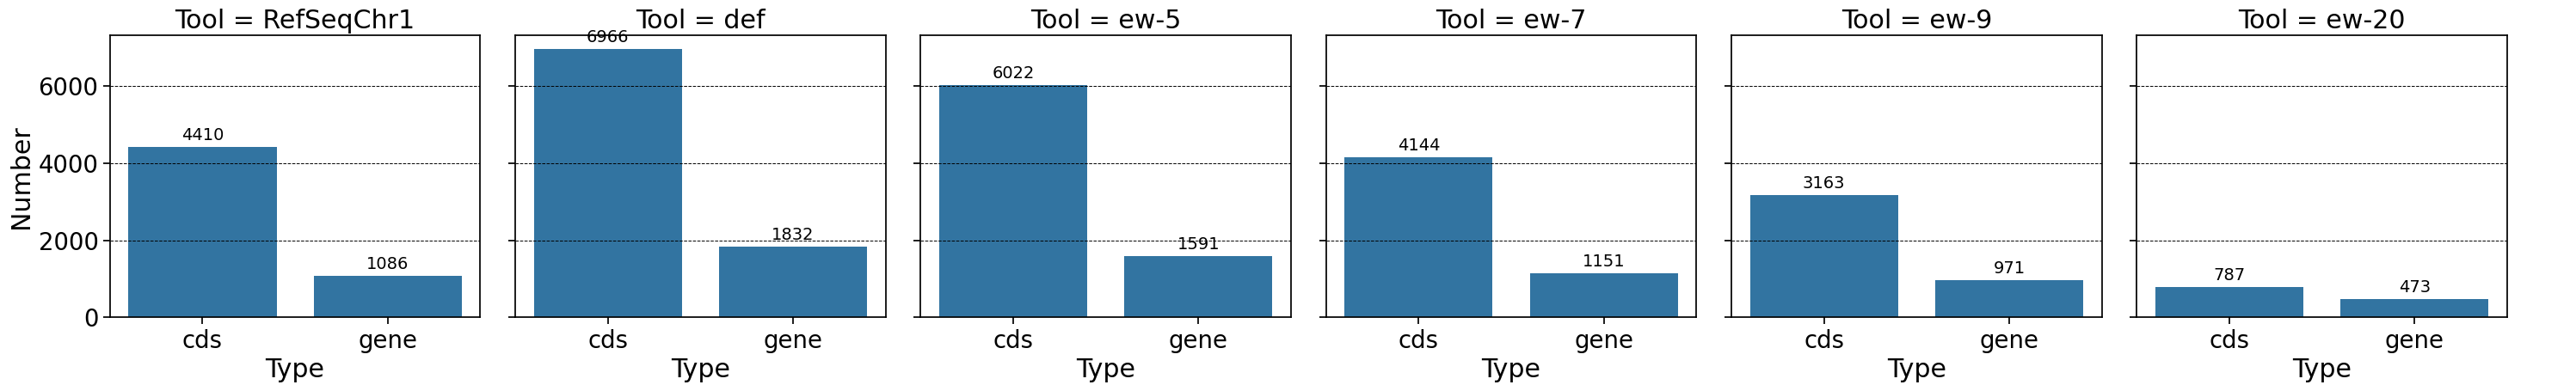

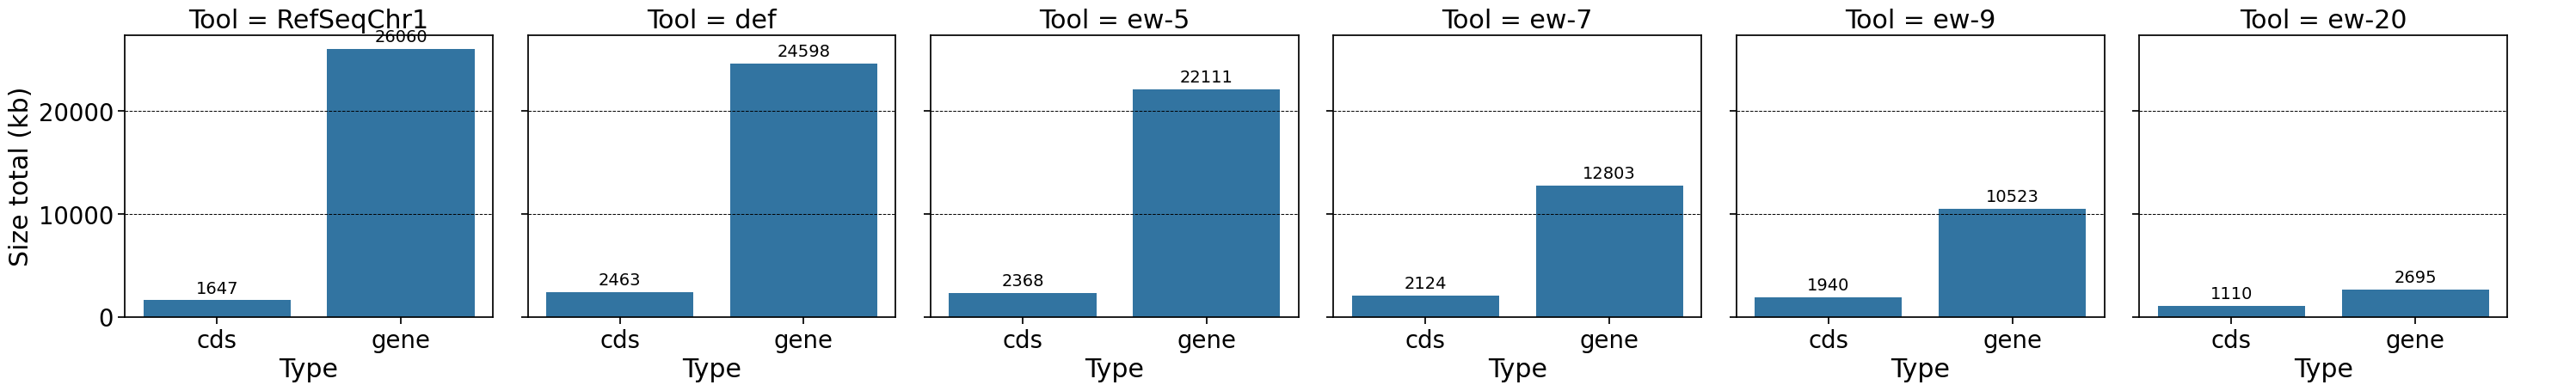

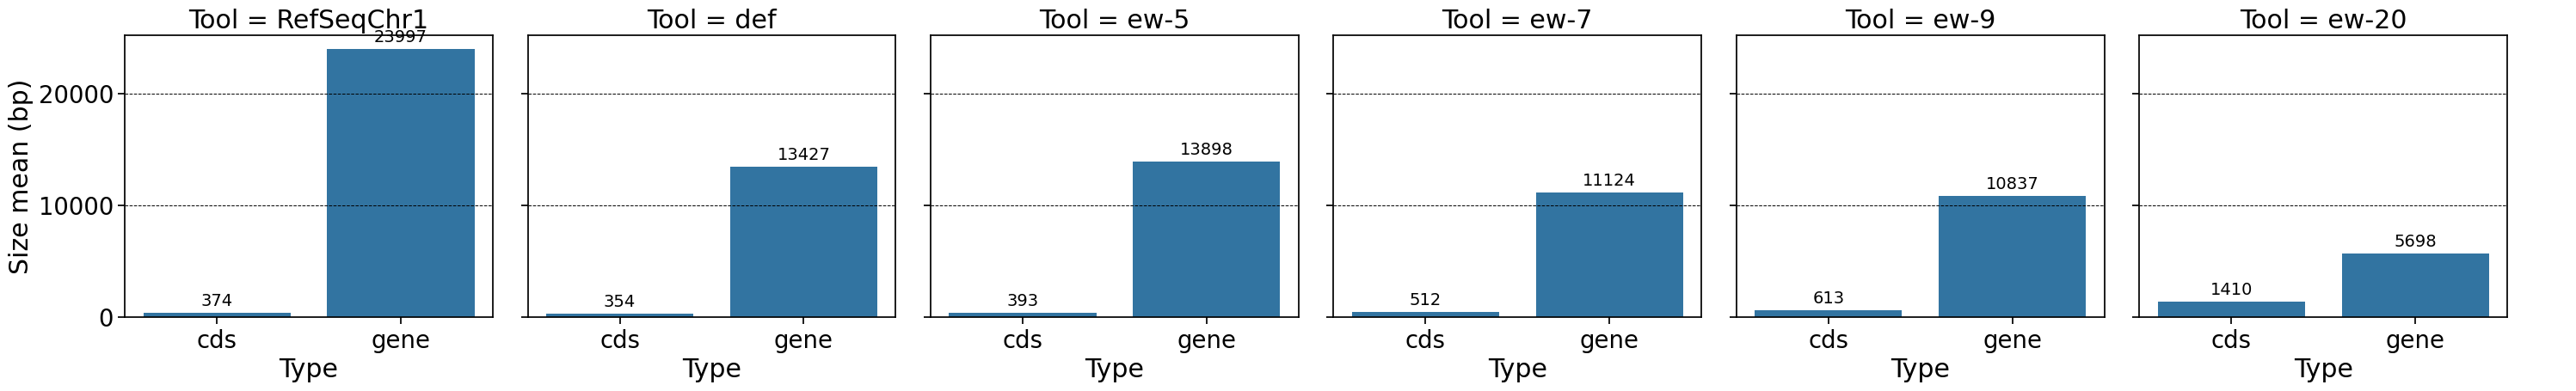

In [138]:
metrics = ['Number','Size total (kb)','Size mean (bp)']
plot_df = summary_df[(summary_df.Type != 'Total') 
                    & (summary_df.Type != 'chromosome')
                    & (summary_df['Full/200+'] == '200+')
                    & (summary_df['Type'].isin(['cds', 'gene']))]

sns.set_context("notebook", font_scale=1.8)

for m in metrics:
    g = sns.catplot(
        data=plot_df, 
        x='Type', 
        y=m,
        col='Tool', 
        kind='bar',
        sharex=False, 
        sharey=True,
        facet_kws={'despine': False},
        col_order=['RefSeqChr1', 'def', 'ew-5', 'ew-7', 'ew-9','ew-20'],
        )  
    g.map(plt.grid, axis='y',color='black', linestyle='--', linewidth=0.7)
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=14) 
    plt.show()

In [132]:
tool_order = ['RefSeqChr1', 'def', 'ew-5', 'ew-7', 'ew-9', 'ew-20']

plot_df['Tool'] = pd.Categorical(plot_df['Tool'], categories=tool_order, ordered=True)
df_sorted = plot_df.sort_values('Tool')
df_sorted

/tmp/9282027/ipykernel_1309891/3480457763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['Tool'] = pd.Categorical(plot_df['Tool'], categories=tool_order, ordered=True)


,File Name,Full/200+,Type,Number,Size total (kb),Size mean (bp),Tool,CatTool
54,RefSeqChr1_longisoforms_200plus_basicelements,200+,cds,4410,1647.24,373.52,RefSeqChr1,RefSeqChr1
55,RefSeqChr1_longisoforms_200plus_basicelements,200+,gene,1086,26060.32,23996.61,RefSeqChr1,RefSeqChr1
50,def_longisoforms_200plus_basicelements,200+,cds,6966,2462.53,353.51,def,def
51,def_longisoforms_200plus_basicelements,200+,gene,1832,24598.24,13426.98,def,def
58,ew-5_longisoforms_200plus_basicelements,200+,cds,6022,2367.56,393.15,ew-5,ew-5
59,ew-5_longisoforms_200plus_basicelements,200+,gene,1591,22111.19,13897.67,ew-5,ew-5
46,ew-7_longisoforms_200plus_basicelements,200+,cds,4144,2123.81,512.50,ew-7,ew-7
47,ew-7_longisoforms_200plus_basicelements,200+,gene,1151,12803.37,11123.69,ew-7,ew-7
42,ew-9_longisoforms_200plus_basicelements,200+,cds,3163,1939.71,613.25,ew-9,ew-9
43,ew-9_longisoforms_200plus_basicelements,200+,gene,971,10523.12,10837.41,ew-9,ew-9


### BUSCO res

In [47]:
busco_df = pd.read_csv(busco_res)

In [62]:
plt_busco_df = busco_df.transpose()
plt_busco_df.index = plt_busco_df.index.map(lambda a : a.replace('BUSCO_','').replace('_CDS',''))
plt_busco_df.columns = plt_busco_df.iloc[0]
plt_busco_df = plt_busco_df.drop('metric')
plt_busco_df = plt_busco_df[['Complete percentage','Fragmented percentage','Missing percentage']].apply(pd.to_numeric)
plt_busco_df.index = plt_busco_df.index.map(lambda a : a.replace('_transcripts',''))
plt_busco_df = plt_busco_df.reindex(['RefSeqChr1', 'def', 'ew-5', 'ew-7', 'ew-9','ew-20'])

(0.0, 10.0)

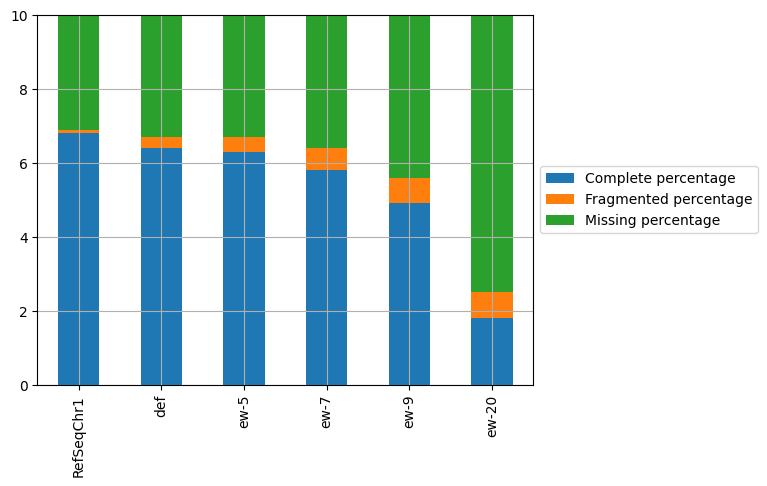

In [63]:
plt_busco_df.plot(kind='bar', stacked = 'True')
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim([0,10])

### GFF compare

In [74]:
gffcomapre_df = pd.read_csv(gffcompare_res)

In [75]:
original_column = gffcomapre_df.columns.drop('comparison')
gffcomapre_df['val'] = gffcomapre_df[original_column].bfill(axis=1).iloc[:, 0]
gffcomapre_df = gffcomapre_df.drop(original_column, axis=1)
gffcomapre_df['comparison'] = gffcomapre_df['comparison'].map(lambda a : a.replace('ew-','ew.'))

In [76]:
gffcomapre_df

,comparison,val
0,ew.20_vs_ew.20-query_mrnas,473
1,ew.20_vs_ew.20-reference_mrnas,473
2,ew.20_vs_ew.20-base_level_Se,100.0
3,ew.20_vs_ew.20-base_level_Pr,100.0
4,ew.20_vs_ew.20-exon_level_Se,100.0
...,...,...
607,ew.7_vs_ew.5-matching_loci,702
608,ew.7_vs_ew.5-missed_exon_prop,85/4143
609,ew.7_vs_ew.5-missed_exon_perc,2.1
610,ew.7_vs_ew.5-novel_exon_prop,1924/6017


In [77]:
gffcomapre_df['metric'] = gffcomapre_df.comparison.map(lambda x : x.split('-')[-1])
gffcomapre_df['reference'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[0])
gffcomapre_df['query'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[1].split('-')[0])
gffcomapre_df['reference_tool'] = gffcomapre_df['reference'].map(lambda x : x.split('_')[-1])
gffcomapre_df['query_tool'] = gffcomapre_df['query'].map(lambda x : x.split('_')[-1])

In [78]:
gffcomapre_df

,comparison,val,metric,reference,query,reference_tool,query_tool
0,ew.20_vs_ew.20-query_mrnas,473,query_mrnas,ew.20,ew.20,ew.20,ew.20
1,ew.20_vs_ew.20-reference_mrnas,473,reference_mrnas,ew.20,ew.20,ew.20,ew.20
2,ew.20_vs_ew.20-base_level_Se,100.0,base_level_Se,ew.20,ew.20,ew.20,ew.20
3,ew.20_vs_ew.20-base_level_Pr,100.0,base_level_Pr,ew.20,ew.20,ew.20,ew.20
4,ew.20_vs_ew.20-exon_level_Se,100.0,exon_level_Se,ew.20,ew.20,ew.20,ew.20
...,...,...,...,...,...,...,...
607,ew.7_vs_ew.5-matching_loci,702,matching_loci,ew.7,ew.5,ew.7,ew.5
608,ew.7_vs_ew.5-missed_exon_prop,85/4143,missed_exon_prop,ew.7,ew.5,ew.7,ew.5
609,ew.7_vs_ew.5-missed_exon_perc,2.1,missed_exon_perc,ew.7,ew.5,ew.7,ew.5
610,ew.7_vs_ew.5-novel_exon_prop,1924/6017,novel_exon_prop,ew.7,ew.5,ew.7,ew.5


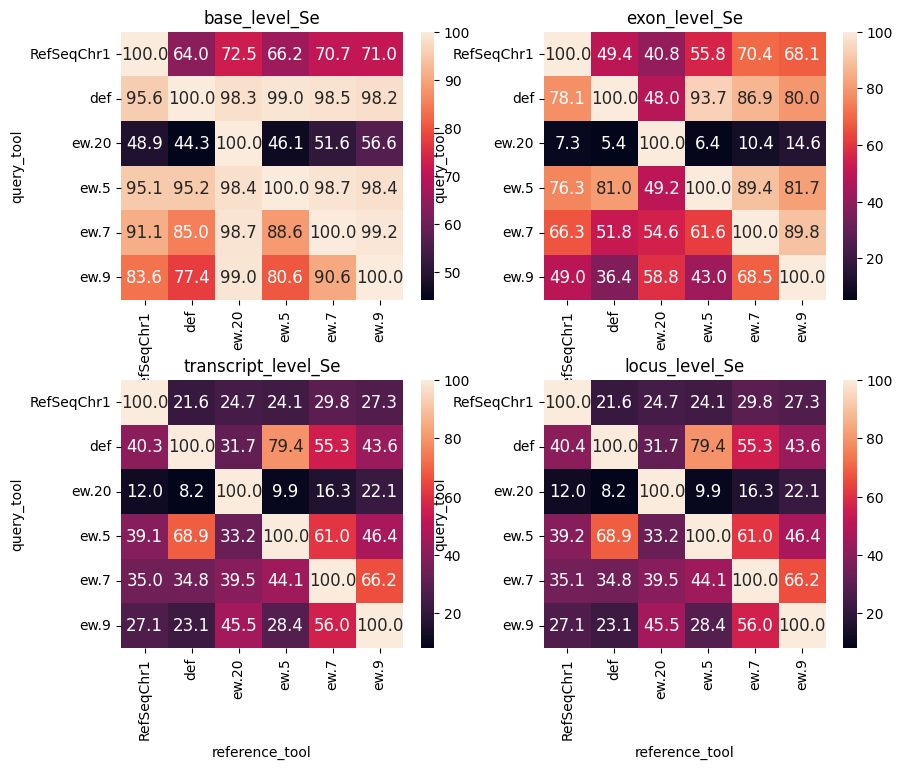

In [79]:
metrics = ['base_level_Se','exon_level_Se',  'transcript_level_Se','locus_level_Se']

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for m,ax in zip(metrics, axs.flat):

    matrix = gffcomapre_df[gffcomapre_df.metric == m].pivot(index="query_tool",
                                                            columns="reference_tool",
                                                            values="val").apply(pd.to_numeric)
    sns.heatmap(data = matrix,
                annot=True,fmt=".1f",
                annot_kws={"size": 12},
                ax=ax)
    ax.set_title(m)

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()

In [84]:
def calculate_f1(precision, recall):
    """Calculate the F1 score given precision and recall."""
    if precision + recall == 0:
        return 0
    return round(2 * (precision * recall) / (precision + recall),1)

In [103]:
def add_f1_scores(df):
    """
    Compute F1 scores for base, exon and locus levels from a DataFrame, grouping by Species, Genus, and Query.

    Parameters:
    df (pd.DataFrame): DataFrame with columns ['metric', 'val', 'Species', 'Genus', 'query', "training_size","training_type"].

    Returns:
    pd.DataFrame: A new DataFrame with F1 scores computed for each species-query combination.
    """
    
    # Pivot the data for easier access
    pivot_df = df.pivot(index=["query"], columns="metric", values="val").reset_index()

    # Calculate F1 scores
    pivot_df["base_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("base_level_Pr", 0), row.get("base_level_Se", 0)), axis=1
    )
    pivot_df["exon_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("exon_level_Pr", 0), row.get("exon_level_Se", 0)), axis=1
    )
    pivot_df["locus_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("locus_level_Pr", 0), row.get("locus_level_Se", 0)), axis=1
    )

    result_df = pivot_df.melt(id_vars=['query'],
           value_vars=['base_level_Pr','base_level_Se','exon_level_Pr',
                       'exon_level_Se','locus_level_Pr','locus_level_Se',
                       'base_level_F1','exon_level_F1','locus_level_F1'])
    
    result_df['measure'] = result_df['metric'].map(lambda x : x.split('_')[-1])
    result_df['level'] = result_df['metric'].map(lambda x : x.split('_')[0])
    
    return result_df

In [107]:
metrics = ['base_level_Se', 'base_level_Pr',
           'exon_level_Se', 'exon_level_Pr',
           'locus_level_Se', 'locus_level_Pr']

acc_df = pd.DataFrame()

for f in [gffcompare_res]:
    gffcomapre_df = pd.read_csv(f)
    original_column = gffcomapre_df.columns.drop('comparison')
    gffcomapre_df['val'] = gffcomapre_df[original_column].bfill(axis=1).iloc[:, 0]
    gffcomapre_df = gffcomapre_df.drop(original_column, axis=1)
    gffcomapre_df['comparison'] = gffcomapre_df['comparison'].map(lambda a : a.replace('ew-','ew'))
    
    gffcomapre_df['metric'] = gffcomapre_df.comparison.map(lambda x : x.split('-')[-1])
    gffcomapre_df['measure'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[-1])
    gffcomapre_df['level'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[0])
    
    gffcomapre_df['reference'] = gffcomapre_df.comparison.map(lambda x : x.split('_')[0])
    gffcomapre_df['query'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[-1].split('-')[0])

    # only keep when reference is RefSeq and keep only accuracy metrics
    gffcomapre_df = gffcomapre_df[(gffcomapre_df['reference'] == 'RefSeqChr1') & (gffcomapre_df['query'] != 'RefSeqChr1')]
    gffcomapre_df = gffcomapre_df[gffcomapre_df.metric.isin(metrics)]
    gffcomapre_df.val = pd.to_numeric(gffcomapre_df.val)
    
    acc_df = pd.concat([acc_df, gffcomapre_df], axis=0)


acc_df = acc_df.drop_duplicates().reset_index()

In [108]:
f1_df = add_f1_scores(acc_df)

In [109]:
f1_df

,query,metric,value,measure,level
0,def,base_level_Pr,64.0,Pr,base
1,ew20,base_level_Pr,72.5,Pr,base
2,ew5,base_level_Pr,66.2,Pr,base
3,ew7,base_level_Pr,70.7,Pr,base
4,ew9,base_level_Pr,71.0,Pr,base
5,def,base_level_Se,95.6,Se,base
6,ew20,base_level_Se,48.9,Se,base
7,ew5,base_level_Se,95.1,Se,base
8,ew7,base_level_Se,91.1,Se,base
9,ew9,base_level_Se,83.6,Se,base


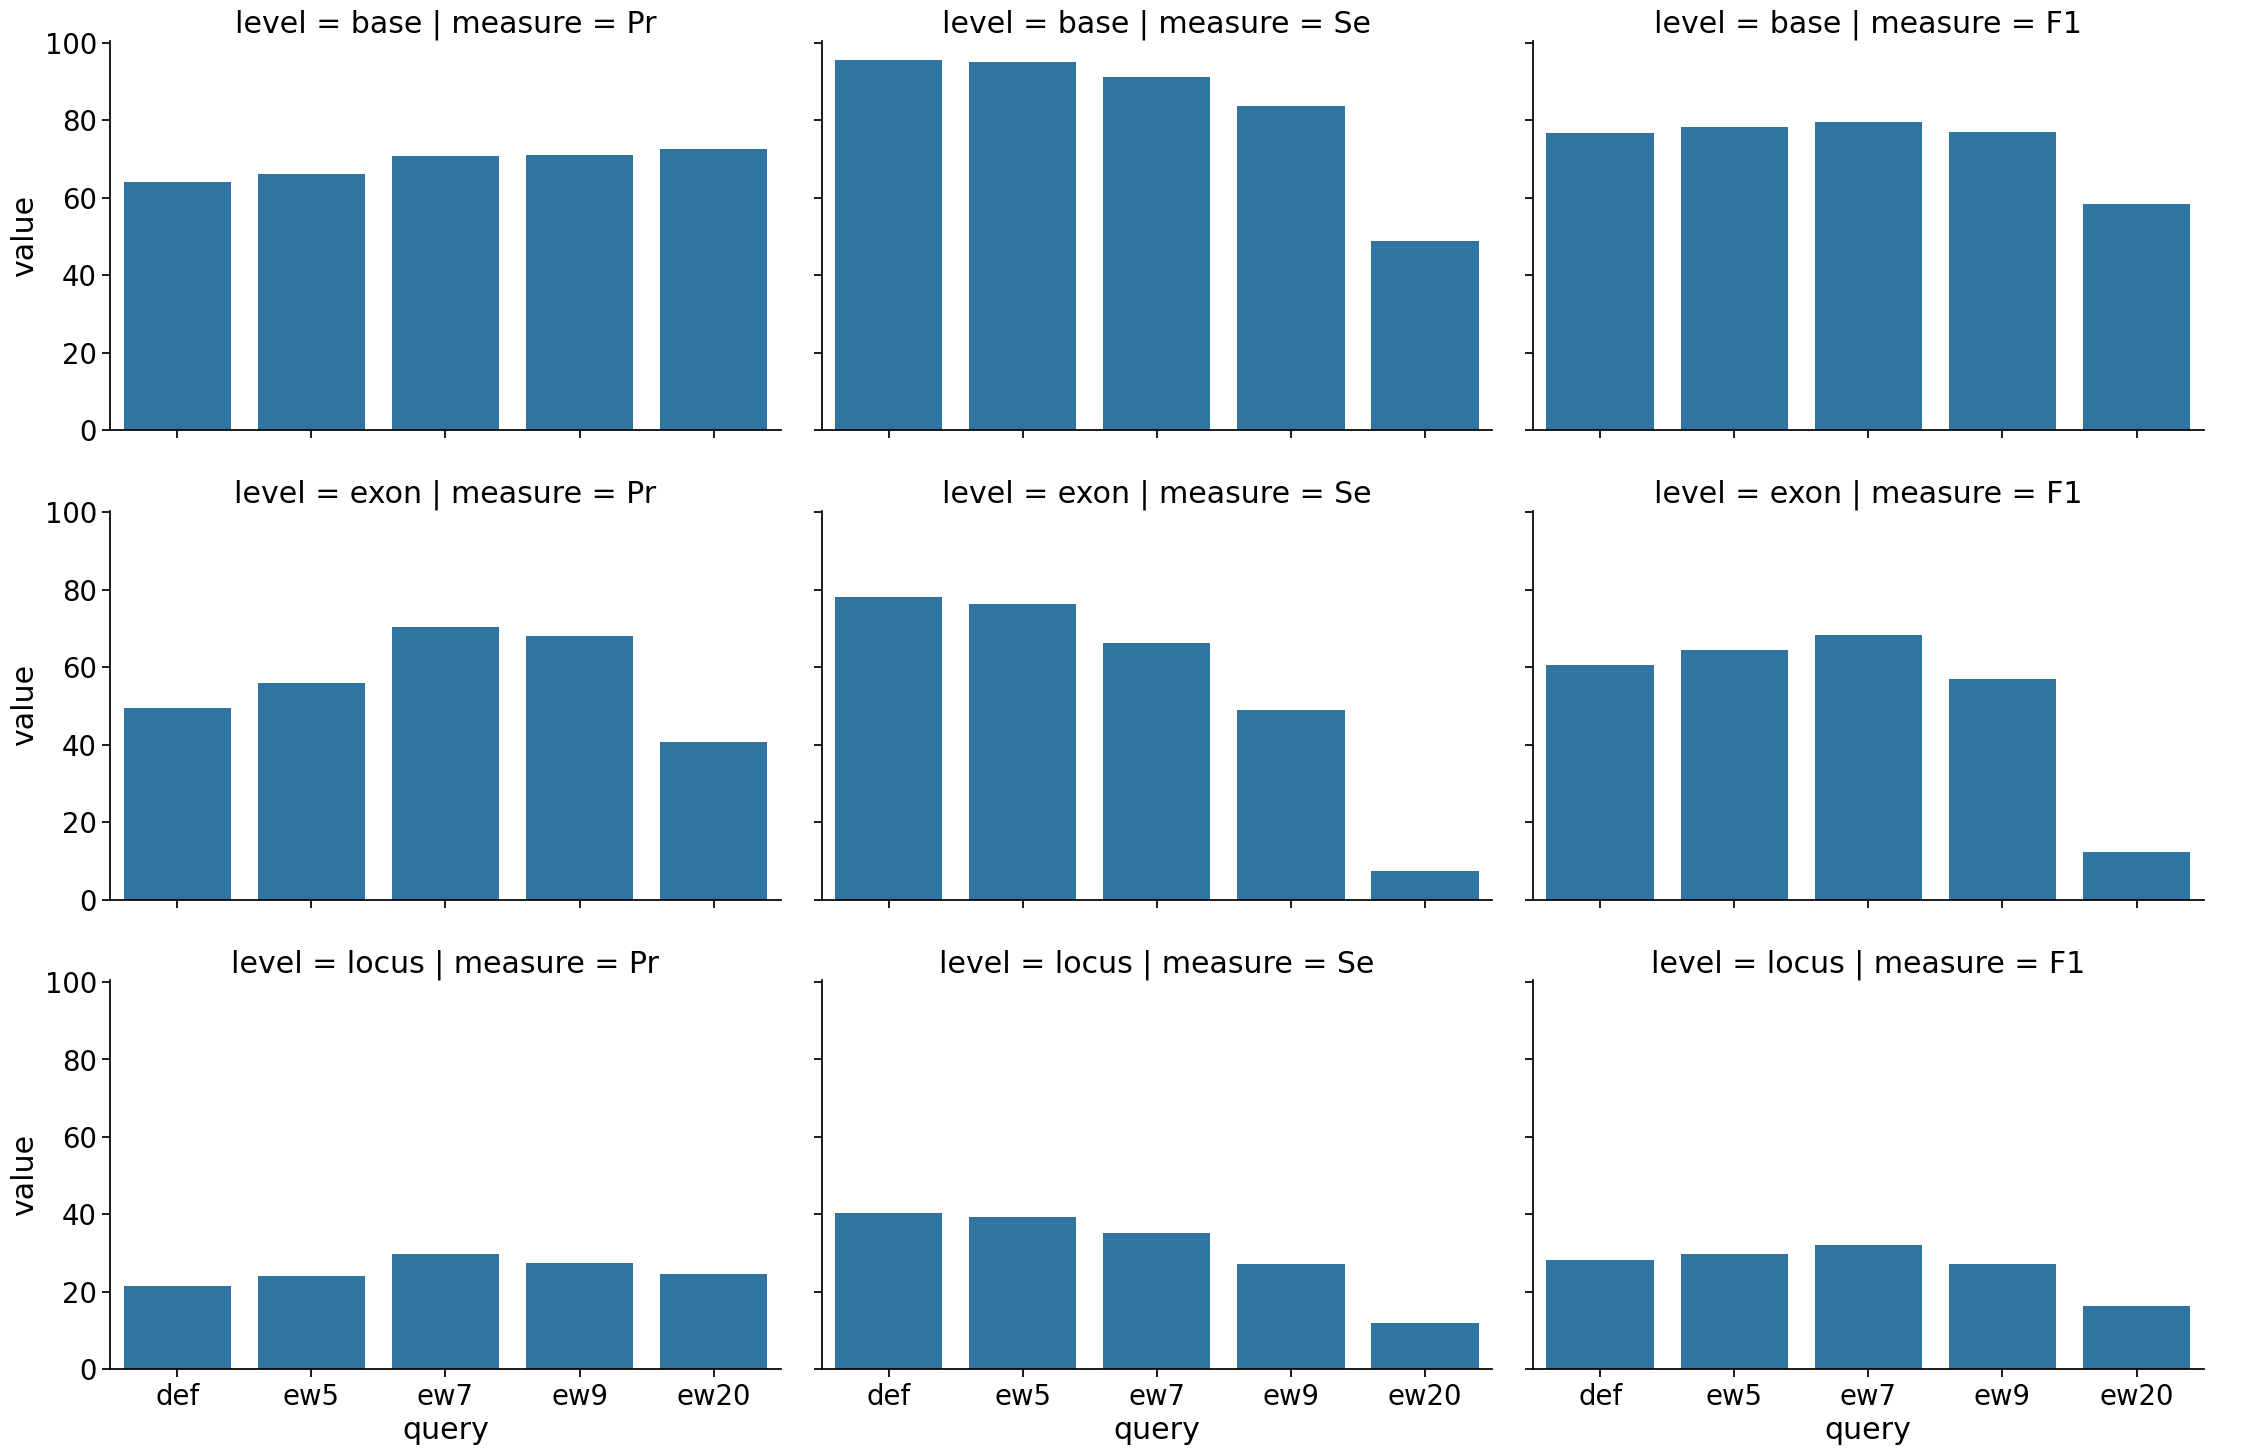

In [140]:
a = sns.catplot(data = f1_df, 
            x = 'query',
            y = 'value',
            col = 'measure',
            row = 'level',
            kind = 'bar',
            order = ['def', 'ew5', 'ew7', 'ew9','ew20'],
            aspect = 1.5
            )